In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("/content/job_dataset.csv")
print(df.head())

   work_year                             job_title  job_category  \
0       2022  Machine Learning Engineer  in office      Analysis   
1       2020                Statistician  (Remote)         ML/AI   
2       2022           Machine Learning Engineer           ML/AI   
3       2022               Data Analyst  in office         ML/AI   
4       2020                        Statistician    Data Science   

  salary_currency  salary  salary_in_usd employee_residence experience_level  \
0             EUR  186597         136086                 US               MI   
1             JPY  110630          67982                 JP               EX   
2             INR   61280         153309                 UK               MI   
3             JPY  154130         135242                 DE               SE   
4             EUR  172312          35156                 UK               MI   

  employment_type work_setting company_location company_size  
0              CT       Remote               DE

In [3]:
#Explore dataset
print('Data Shape:\n',df.shape,'\n')
print('\nData Info:\n',df.info())

Data Shape:
 (5000, 12) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           5000 non-null   int64 
 1   job_title           5000 non-null   object
 2   job_category        4500 non-null   object
 3   salary_currency     4500 non-null   object
 4   salary              5000 non-null   int64 
 5   salary_in_usd       5000 non-null   int64 
 6   employee_residence  5000 non-null   object
 7   experience_level    4500 non-null   object
 8   employment_type     5000 non-null   object
 9   work_setting        5000 non-null   object
 10  company_location    5000 non-null   object
 11  company_size        4500 non-null   object
dtypes: int64(3), object(9)
memory usage: 468.9+ KB

Data Info:
 None


In [4]:
#Handling Missing Values
print(df.isnull().sum())
df.fillna(method='ffill', inplace=True)

work_year               0
job_title               0
job_category          500
salary_currency       500
salary                  0
salary_in_usd           0
employee_residence      0
experience_level      500
employment_type         0
work_setting            0
company_location        0
company_size          500
dtype: int64


/tmp/ipykernel_47558/2525081792.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
#Handling Duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


In [6]:
#Checking data types
print(df.dtypes)

work_year              int64
job_title             object
job_category          object
salary_currency       object
salary                 int64
salary_in_usd          int64
employee_residence    object
experience_level      object
employment_type       object
work_setting          object
company_location      object
company_size          object
dtype: object


In [7]:
df['work_year'] = df['work_year'].astype(int)

In [8]:
#Statistical Analysis
print(df.describe())

        work_year         salary  salary_in_usd
count  5000.00000    5000.000000    5000.000000
mean   2020.97680  102046.307200  114076.995800
std       0.81951   70853.626492   49113.807687
min    2020.00000 -198754.000000   30016.000000
25%    2020.00000   64295.500000   71343.750000
50%    2021.00000  110636.000000  114167.000000
75%    2022.00000  153104.750000  156665.750000
max    2022.00000  199924.000000  199985.000000


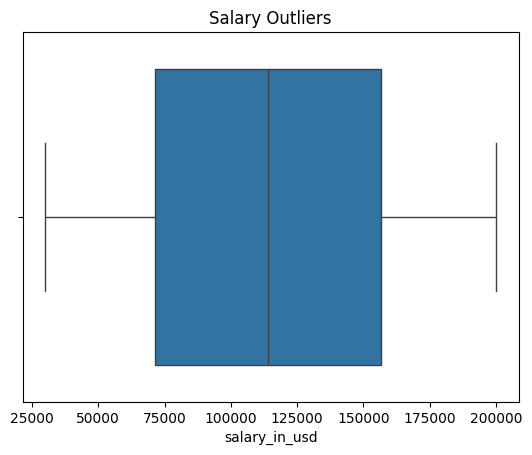

In [9]:
#Detecting Outliers
sns.boxplot(x=df['salary_in_usd'])
plt.title("Salary Outliers")
plt.show()

In [10]:
#Removing Outliers
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['salary_in_usd'] >= lower) &
        (df['salary_in_usd'] <= upper)]

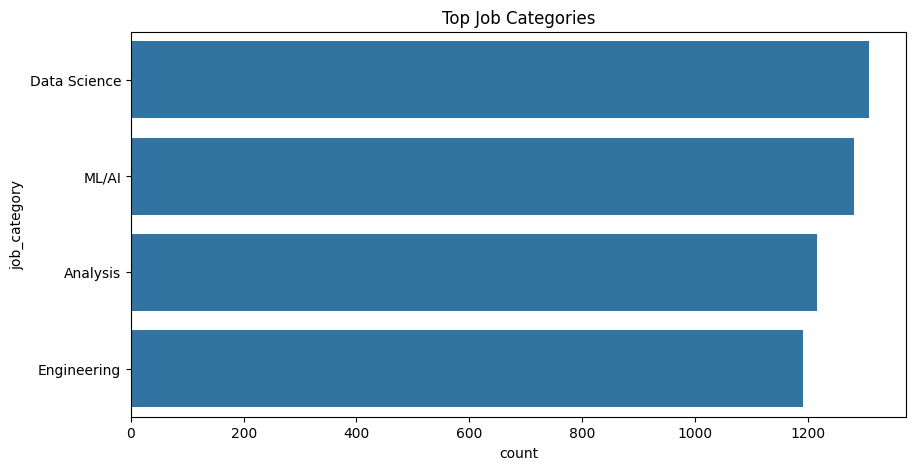

In [11]:
#Data Visualization
plt.figure(figsize=(10,5))
sns.countplot(y='job_category',
              data=df,
              order=df['job_category'].value_counts().index)

plt.title("Top Job Categories")
plt.show()

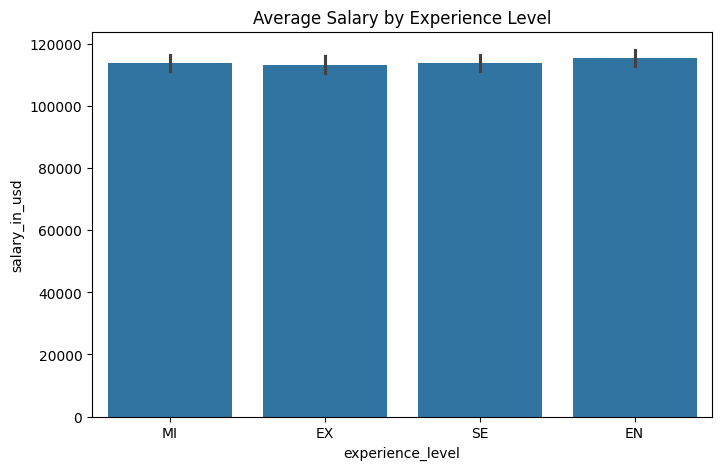

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='experience_level',
            y='salary_in_usd',
            data=df)
plt.title("Average Salary by Experience Level")
plt.show()

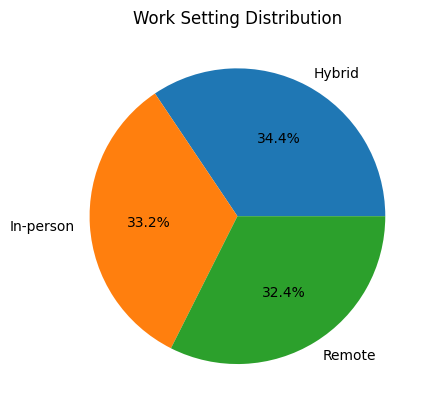

In [13]:
df['work_setting'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Work Setting Distribution")
plt.ylabel("")
plt.show()

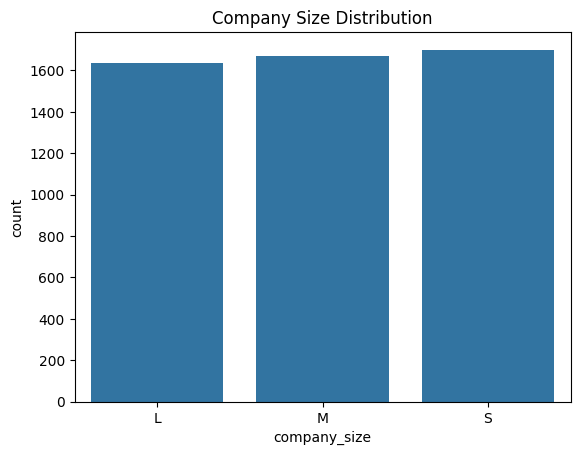

In [14]:
sns.countplot(x='company_size', data=df)
plt.title("Company Size Distribution")
plt.show()

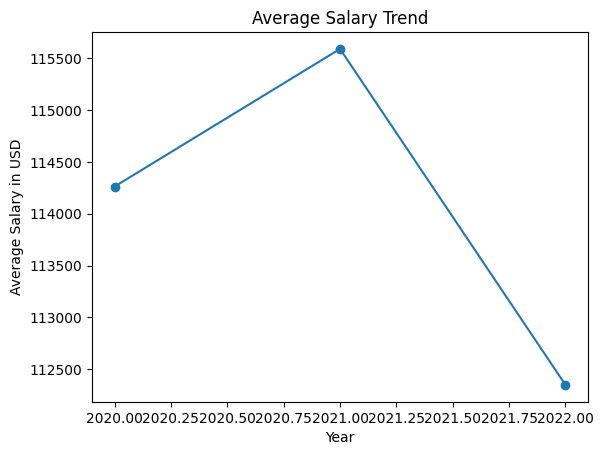

In [15]:
salary_trend = df.groupby('work_year')['salary_in_usd'].mean()
salary_trend.plot(marker='o')

plt.title("Average Salary Trend")
plt.xlabel("Year")
plt.ylabel("Average Salary in USD")
plt.show()

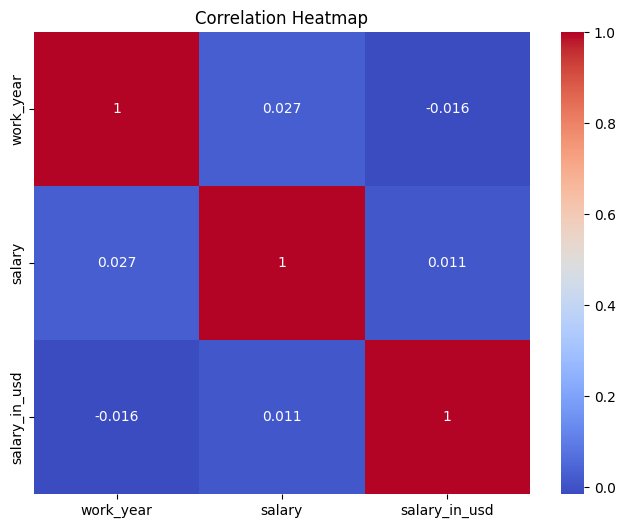

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df.to_csv("cleaned_job_dataset.csv",
          index=False)